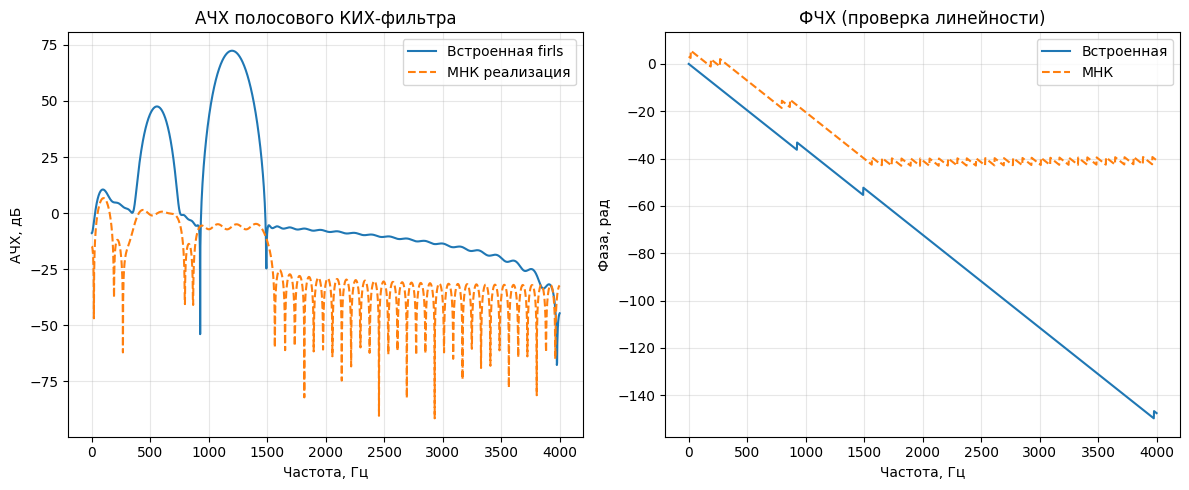

Средняя групповая задержка (встроенная): 0.04 отсчётов
Средняя групповая задержка (МНК): 0.01 отсчётов
Теоретическая групповая задержка: 50.00 отсчётов


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firls, freqz

# Параметры согласно заданию
fs = 8000  # частота дискретизации, Гц
nyq = fs / 2
N = 101  # порядок фильтра (нечётный для Типа I с линейной ФЧХ)
M = (N - 1) // 2

# Целевая АЧХ согласно заданию:
# 50-150 Гц: усиление ×2, 350-750 Гц: ×1, 900-1500 Гц: ×0.5
def H_desired(f):
    f = np.abs(np.array(f))
    result = np.zeros_like(f)
    result[(f >= 50) & (f <= 150)] = 2.0
    result[(f >= 350) & (f <= 750)] = 1.0
    result[(f >= 900) & (f <= 1500)] = 0.5
    return result

# Частотная сетка для МНК
L = 4000
f_grid = np.linspace(0, nyq, L)
omega_grid = 2 * np.pi * f_grid / fs
d = H_desired(f_grid)

# Матрица системы для Типа I КИХ-фильтра с линейной ФЧХ:
# A(ω) = h[M] + Σ_{n=0}^{M-1} 2h[n]cos(ω(M-n))
F = np.zeros((L, M + 1))
for n in range(M):
    F[:, n] = 2 * np.cos(omega_grid * (M - n))
F[:, M] = 1.0

# МНК-решение переопределённой СЛАУ
h_sym = np.linalg.lstsq(F, d, rcond=None)[0]

# Формирование полной симметричной импульсной характеристики
h_custom = np.zeros(N)
h_custom[M] = h_sym[M]                    # Центральный коэффициент
h_custom[:M] = h_sym[:M]                  # Левая половина
h_custom[M+1:] = h_sym[:M][::-1]          # Правая половина (зеркальная)

# Встроенная функция firls
bands = [0, 50, 150, 350, 750, 900, 1500, nyq]
desired = [0, 2, 2, 1, 1, 0.5, 0.5, 0]
h_builtin = firls(N, bands, desired, fs=fs)

# Расчёт АЧХ
w, H_builtin = freqz(h_builtin, worN=2000, fs=fs)
_, H_custom = freqz(h_custom, worN=2000, fs=fs)

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(w, 20 * np.log10(np.abs(H_builtin) + 1e-10), label='Встроенная firls')
plt.plot(w, 20 * np.log10(np.abs(H_custom) + 1e-10), label='МНК реализация', linestyle='--')
plt.title('АЧХ полосового КИХ-фильтра')
plt.xlabel('Частота, Гц')
plt.ylabel('АЧХ, дБ')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(w, np.unwrap(np.angle(H_builtin)), label='Встроенная')
plt.plot(w, np.unwrap(np.angle(H_custom)), label='МНК', linestyle='--')
plt.title('ФЧХ (проверка линейности)')
plt.xlabel('Частота, Гц')
plt.ylabel('Фаза, рад')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Проверка групповой задержки (должна быть постоянной для линейной ФЧХ)
group_delay_builtin = -np.diff(np.unwrap(np.angle(H_builtin))) / np.diff(w)
group_delay_custom = -np.diff(np.unwrap(np.angle(H_custom))) / np.diff(w)

print(f"Средняя групповая задержка (встроенная): {np.mean(group_delay_builtin):.2f} отсчётов")
print(f"Средняя групповая задержка (МНК): {np.mean(group_delay_custom):.2f} отсчётов")
print(f"Теоретическая групповая задержка: {M:.2f} отсчётов")

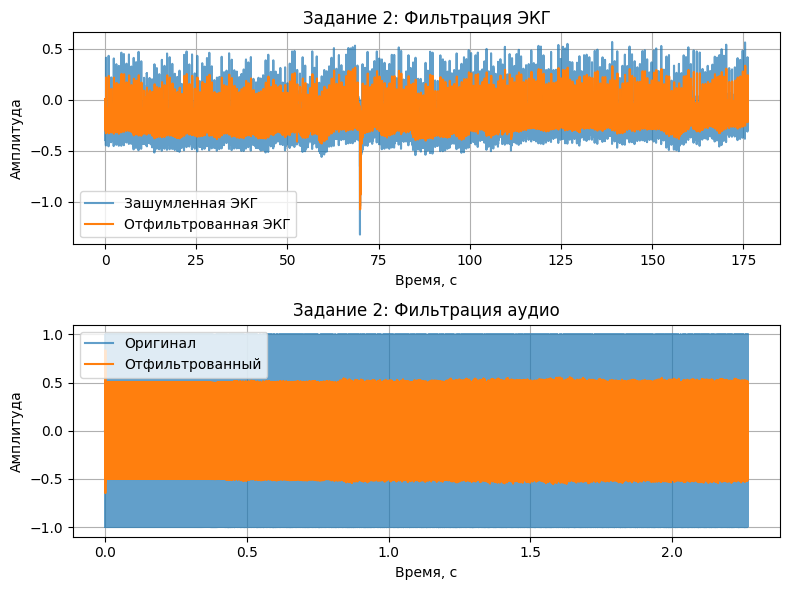

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import firls, lfilter

# --- Обработка аудиофайла tune.wav ---
fs_audio, x_audio = wavfile.read('tune.wav')
if x_audio.ndim > 1:
    x_audio = x_audio.mean(axis=1)
x_audio = x_audio.astype(np.float64)
x_audio /= np.max(np.abs(x_audio))

# Определение частоты помехи по максимуму спектра
X = np.fft.rfft(x_audio)
freqs = np.fft.rfftfreq(len(x_audio), 1 / fs_audio)
idx_noise = np.argmax(np.abs(X)[1:]) + 1
f_noise = freqs[idx_noise]

# Режекторный КИХ-фильтр с линейной ФЧХ
bw = 20
h_audio = firls(101, [0, f_noise - bw, f_noise + bw, fs_audio / 2], [1, 0, 1, 1], fs=fs_audio)
y_audio = lfilter(h_audio, 1, x_audio)

# --- Обработка файла ЭКГ ecg.dat ---
ecg_data = np.loadtxt('ecg.dat')
t_ecg = ecg_data[:, 0]
x_ecg = ecg_data[:, 1]
fs_ecg = int(round(1 / (t_ecg[1] - t_ecg[0])))

# Режекторный КИХ-фильтр на 50 Гц
f_50 = 50
h_ecg = firls(101, [0, f_50 - 2, f_50 + 2, fs_ecg / 2], [1, 0, 1, 1], fs=fs_ecg)
y_ecg = lfilter(h_ecg, 1, x_ecg)

# --- Визуализация результатов ---
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(t_ecg, x_ecg, label='Зашумленная ЭКГ', alpha=0.7)
plt.plot(t_ecg, y_ecg, label='Отфильтрованная ЭКГ')
plt.title('Задание 2: Фильтрация ЭКГ')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
t_audio = np.arange(len(x_audio)) / fs_audio
plt.plot(t_audio[:len(y_audio) // 10], x_audio[:len(y_audio) // 10], label='Оригинал', alpha=0.7)
plt.plot(t_audio[:len(y_audio) // 10], y_audio[:len(y_audio) // 10], label='Отфильтрованный')
plt.title('Задание 2: Фильтрация аудио')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()